In `Asthma vs air qualiy` I look at how asthma outcomes are related to air quality, including the effects of demographics and spatial autocorrelation. Some of the details of the model selection process are expanded here, for completeness and transparency.
- Collinearity of predictors
- Choice of spatial weights
- Spatial distribution of error terms in non-spatial OLS models
- Modeling spatial lag in the dependent variable aka spatial lag model

In [1]:
from functools import reduce

import matplotlib
import matplotlib.pyplot as plt

import numpy as np
import pandas as pd
import geopandas as gpd
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from libpysal.weights import Queen, KNN
from libpysal import weights
from esda.moran import Moran
import spreg

from air_brain.asthma import build_dataset
from air_brain.tables import ols2df, spreg2df, p_col_style

In [2]:
df = build_dataset()
dep_vars = ["ED_visits_frac", "ED_hosp_frac", "UC_visits_frac", "Asthma_use_frac"]
indep_vars = ["PM25", "dpm", "lowincome", "poc"]
indep_to_use = {"ED_visits_frac": ["PM25", "dpm"],
                "ED_hosp_frac": ["PM25", "dpm"],
                "UC_visits_frac": ["PM25"],
                "Asthma_use_frac": ["PM25"]}
demos = ["lowincome", "poc"]
combo_indep_vars = {"ED_visits_frac": ["PM25_dpm_mean", "poc_lowincome_pca"],
                    "ED_hosp_frac": ["PM25_dpm_mean", "poc_lowincome_pca"],
                    "UC_visits_frac": ["PM25", "poc_lowincome_pca"],
                    "Asthma_use_frac": ["PM25", "poc_lowincome_pca"]}
RADIUS_EARTH_MILES = 3959

# Collinearity of predictors

The four variables we want to include in our models are all very collinear with each other, except PoC, which is only moderately collinear. I'm using the variance inflation factor (VIF) with a cutoff of 5.

In [3]:
cols = ["PM25", "dpm", "lowincome", "poc"]
for idx in range(len(cols)):
    val = variance_inflation_factor(df[cols], idx)
    print(cols[idx], val)

PM25 7.805840271300308
dpm 8.44092870162693
lowincome 10.360421525696621
poc 4.833696233666254


The high collinearity between PM 2.5 and diesel PM is expected, since diesel PM is (generally) a subset of PM 2.5.

We also observe collinearity for the models that have PM 2.5 but not diesel PM, particularly in the low income demographic variable.

In [4]:
cols = ["PM25", "lowincome", "poc"]
for idx in range(len(cols)):
    val = variance_inflation_factor(df[cols], idx)
    print(cols[idx], val)

PM25 4.164822439358602
lowincome 9.628665545617753
poc 4.830049297361873


This collinearity isn't surprising, from a sociodemographic perspective. Furthermore, we observe in the main results that all these variables are pairwise significantly correlated with each other.

Collinearity is a barrier to deriving meaningful results from the dataset, because it inflates the standard errors of the regression models. Predictors that may in fact have an important effect on the outcomes may look insignificant because their effect is blurred from the inclusion of other highly correlated variables. There are a handful of standard ways of handling collinearity for explanatory models(*):
- Drop variables
- Combine variables, e.g. as mean or difference
- Combine variables, e.g. as PCA/factor analysis

None of these options are ideal, particularly since I have so few variables to start with. I want to keep both PM 2.5 and diesel PM for the emergency department outcomes, since I find it interesting that diesel PM is predictive of emergency outcomes but not urgent care or asthma care generally. I want to keep both low income and PoC as demographics to control for because I believe that they represent different barriers to healthcare. And I want to include both air quality and demographics, because I want to demonstrate an impact of air quality separate from the correlation of poor air quality with barriers to healthcare.

(*) I'm ignoring ridge regression because, in my understanding, assigning significance to coefficients in a ridge regression model is not considered reliable. And since the point of an explanatory regression model is to determine the importance of predictors' effects on outcomes, this difficulty makes ridge regression a non-starter.

But maybe I'm worrying for nothing! What happens when I run the regressions with all variables, ignoring the collinearity?

In [5]:
demo_vars = ["lowincome", "poc"]
indep_to_use = {"ED_visits_frac": ["PM25", "dpm"],
                "ED_hosp_frac": ["PM25", "dpm"],
                "UC_visits_frac": ["PM25"],
                "Asthma_use_frac": ["PM25"]}

In [6]:
# linear regression, predicting asthma encounter fraction using air quality as well as demographics,
# including all variables
ols_res = dict()
for col in dep_vars:
    mod = sm.OLS(df[col], df[indep_to_use[col] + demo_vars + ["intercept"]])
    res = mod.fit()
    ols_res[col] = res
ols2df(ols_res)[["coef", "std err", "p"]].style.pipe(p_col_style)

Without the demographics, all four of these outcomes had their associated air quality measures as significant predictors. With both demographics, PM 2.5 is only a significant predictor of urgent care and general asthma use, and neither air quality measure is predictive of emergency department care. However, both demographics are significant predictors of emergency department care, and PoC is predictive of general asthma care.

With the collinearities among the variables, I'm not sure if the losses of significance in the air quality variables are a real reflection of the relationships among these variables, or whether they are due to variance inflation. 

My primary question is whether air quality predicts asthma outcomes, even when controlling for demographics and spatial autocorrelation. I am interested in the differences between PM 2.5 and diesel PM, as well as the differences between PoC and low income. However, the high degree of collinearity in my relatively small dataset means that I will struggle to interpret the results of regressions using all four variables. Therefore, the best way forward is to combine the air quality measures into a single variable, and the demographic measures into another single variable. This method will still allow me to control for demographics while being able to trust negative results.

### Combining predictors

The most obvious ways to combine the variables are
- maximum
- sum or mean
- taking the first component of PCA

It's not immediately obvious which way of combining predictors is best, or whether it may differ by predictor or dependent variable. Without a theoretical justification for any of these, I will look to the data and pick the combination method that results in a variable that maximizes the coefficient of determination R2. This choice argues that the best way of combining variables is the one that is most predictive of the outcome.

In [7]:
# scale PM 2.5 and diesel before combining, because they are on very different scales
df[["PM25_scale", "dpm_scale"]] = StandardScaler().fit_transform(df[["PM25", "dpm"]])
df["PM25_dpm_max"] = df[["PM25_scale", "dpm_scale"]].max(axis=1)
df["PM25_dpm_mean"] = df[["PM25_scale", "dpm_scale"]].mean(axis=1)

# only use combined variable for ED outcomes, because only PM 2.5 was significant for non-ED outcomes
indep_to_use_max = {"ED_visits_frac": ["PM25_dpm_max"],
                    "ED_hosp_frac": ["PM25_dpm_max"],
                    "UC_visits_frac": ["PM25"],
                    "Asthma_use_frac": ["PM25"]}
indep_to_use_mean = {"ED_visits_frac": ["PM25_dpm_mean"],
                     "ED_hosp_frac": ["PM25_dpm_mean"],
                     "UC_visits_frac": ["PM25"],
                     "Asthma_use_frac": ["PM25"]}

# PoC and lowincome are naturally on the same scale, so don't need to re-scale
df["poc_lowincome_max"] = df[["poc", "lowincome"]].max(axis=1)
df["poc_lowincome_mean"] = df[["poc", "lowincome"]].mean(axis=1)

# compute PCA as well
pca_air = PCA(n_components=1)
pca_air.fit(df[["PM25", "dpm"]])
print("Air quality PCA explained variance:  {}".format(pca_air.explained_variance_ratio_[0].round(3)))
df["PM25_dpm_pca"] = pca_air.transform(df[["PM25", "dpm"]])

pca_demo = PCA(n_components=1)
pca_demo.fit(df[["lowincome", "poc"]])
print("Demographics PCA explained variance: {}".format(pca_demo.explained_variance_ratio_[0].round(3)))
df["poc_lowincome_pca"] = pca_demo.transform(df[["lowincome", "poc"]])

Air quality PCA explained variance:  0.894
Demographics PCA explained variance: 0.896


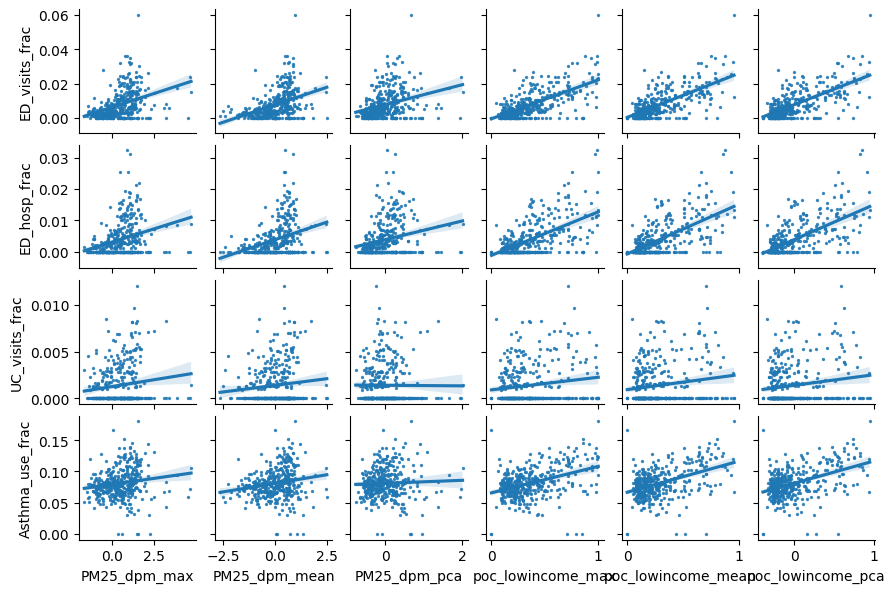

In [8]:
import seaborn as sns
sns.pairplot(df[["PM25_dpm_max", "PM25_dpm_mean", "PM25_dpm_pca", "poc_lowincome_max", "poc_lowincome_mean", "poc_lowincome_pca"] + dep_vars],
             x_vars=["PM25_dpm_max", "PM25_dpm_mean", "PM25_dpm_pca", "poc_lowincome_max", "poc_lowincome_mean", "poc_lowincome_pca"], 
             y_vars=dep_vars, 
             kind="reg", plot_kws={"scatter_kws":{"s": 2}}, height=1.5)

In [9]:
combo_vars = {"PM25_dpm_max": ["ED_visits_frac", "ED_hosp_frac"],
              "PM25_dpm_mean": ["ED_visits_frac", "ED_hosp_frac"],
              "PM25_dpm_pca": ["ED_visits_frac", "ED_hosp_frac"],
              "poc_lowincome_max": ["ED_visits_frac", "ED_hosp_frac", "UC_visits_frac", "Asthma_use_frac"],
              "poc_lowincome_mean": ["ED_visits_frac", "ED_hosp_frac", "UC_visits_frac", "Asthma_use_frac"],
              "poc_lowincome_pca": ["ED_visits_frac", "ED_hosp_frac", "UC_visits_frac", "Asthma_use_frac"],
             }

all_res = list()
for indep in combo_vars:
    ols_res = dict()
    for dep in combo_vars[indep]:
        mod = sm.OLS(df[dep], df[[indep] + ["intercept"]])
        res = mod.fit()
        ols_res[dep] = res
    all_res.append(ols2df(ols_res)[["coef", "std err", "p", "R2"]])
pd.concat(all_res).sort_values(["dep_var", "R2"]).style.pipe(p_col_style)

These results suggest that I should use the mean to combine air quality measures, and PCA to combine demographics.

I find this conclusion odd. Using the first principal component is essentially using a weighted average of the two variables. I would expect PCA to always generate better results than a simple average, because it better accounts for the relationships between the variables.

In [10]:
combo_indep_vars = {"ED_visits_frac": ["PM25_dpm_mean", "poc_lowincome_pca"],
                    "ED_hosp_frac": ["PM25_dpm_mean", "poc_lowincome_pca"],
                    "UC_visits_frac": ["PM25", "poc_lowincome_pca"],
                    "Asthma_use_frac": ["PM25", "poc_lowincome_pca"]}

In [11]:
cols = ["PM25_dpm_mean", "poc_lowincome_pca"]
for idx in range(len(cols)):
    val = variance_inflation_factor(df[cols], idx)
    print(cols[idx], val)

PM25_dpm_mean 1.3891119112222916
poc_lowincome_pca 1.3891119112222916


In [12]:
cols = ["PM25", "poc_lowincome_pca"]
for idx in range(len(cols)):
    val = variance_inflation_factor(df[cols], idx)
    print(cols[idx], val)

PM25 1.0000446674570382
poc_lowincome_pca 1.0000446674570382


In [13]:
ols_res = dict()
for col in dep_vars:
    mod = sm.OLS(df[col], df[combo_indep_vars[col] + ["intercept"]])
    res = mod.fit()
    ols_res[col] = res
ols2df(ols_res)[["coef", "std err", "p"]].style.pipe(p_col_style)

# Choice of spatial weights

The first decision when analyzing spatial autocorrelation is what the spatial weights should be. This decision encodes the assumptions about how difference regions influence each other.

Ideally, the choice of spatial weights wouldn't influence the conclusions. Unfortunately, that is not the case in this dataset, as I will show below. 

There are two reasonable choices for spatial weights for this analysis:
- Queen's contiguity: regions that are adjacent to each other on an edge or vertex are related.
- Gaussian kernel: a region is related to all other regions, with the strength of the relationship decreasing as a Gaussian function with distance. This choice requires a choice of the "width" of the Gaussian, i.e. how fast the weights decay with distance.

I'm not including block weights, since I don't have natural blocking units in this dataset. I'm also not including KNN, because the size of the spatial regions varies so dramatically, i.e. the area occupied by one "neighbor" is extremely variable. Additionally, there are many possible distance weighting kernels that could be used, but Gaussian is the natural choice for dispersion of a contaminant in air.

In [14]:
def make_lag(df, col, weight_class, weight_kwargs=dict()):
    # spatial lag weights
    w = weight_class.from_dataframe(df, use_index=False, **weight_kwargs)
    # standardize by rows to use averages instead of sums
    w.transform = "R"
    # compute the spatial lag of column col
    w_col = weights.spatial_lag.lag_spatial(w, df[col])
    w_series = pd.Series(w_col, name="w_{}".format(col), index=df.index)
    return w_series

def test_weights(df, indep_vars, dep_vars, weight_class, weight_kwargs=dict()):
    # spatial lag weights
    w = weight_class.from_dataframe(df, use_index=False, **weight_kwargs)
    # standardize by rows to use averages instead of sums
    w.transform = "R"

    # compute the spatial lag of all independent variables
    # using row-standardized weights defined above
    wx = df[indep_vars].apply(lambda y: weights.spatial_lag.lag_spatial(w, y))
    # rename columns to w_*
    wx = wx.rename(columns=lambda c: "w_" + c)
    # glue onto other data
    dfx= df.join(wx)

    # linear regression, predicting asthma encounter fraction using each variable individually
    all_res = list()
    for indep in indep_vars:
        ols_res = dict()
        for dep in dep_vars:
            mod = sm.OLS(dfx[dep], dfx[[indep, "w_{}".format(indep), "intercept"]])
            res = mod.fit()
            ols_res[dep] = res
        all_res.append(ols2df(ols_res)[["coef", "std err", "p", "R2"]])
    res_df = pd.concat(all_res)
    
    return w, dfx, res_df

### Queen's contiguity
What are the conclusions if we use Queen's contiguity for all weights?

First, check if the variables are spatially autocorrelated when using this weight.

In [15]:
# spatial lag weights from Queen contiguity
w_queen = weights.Queen.from_dataframe(df, use_index=False)
# standardize by rows to use averages instead of sums
w_queen.transform = "R"
# compute Moran's I
res_dict = {}
for col in ["PM25", "dpm", "lowincome", "poc"] + dep_vars:
    moran = Moran(df[col], w_queen)
    res_dict[col] = {"I": moran.I, "p": moran.p_sim}
res = pd.DataFrame(res_dict).transpose()
res

,I,p
PM25,0.957093,0.001
dpm,0.778897,0.001
lowincome,0.553072,0.001
poc,0.652880,0.001
ED_visits_frac,0.412046,0.001
ED_hosp_frac,0.308218,0.001
UC_visits_frac,0.139003,0.001
Asthma_use_frac,0.239554,0.001


All variables are significantly spatially autocorrelated. Note that Moran's I ranges between -1 (dissimilar values cluster) to 1 (similar values cluster). Air quality measures have extremely high values for Moran's I, particularly PM 2.5, as expected from mapping the variables.

What happens when we include spatial autocorrelation in the regression models? For simplicity, I will consider each variable individually. Recall that each independent variable, on its own, was a significant predictor of each outcome variable, with the exception of diesel PM for urgent care and overall asthma encounters.

In [16]:
# compute the spatial lag of all independent variables (air quality + demographics)
# using row-standardized weights defined above
wx_queen = df[indep_vars].apply(lambda y: weights.spatial_lag.lag_spatial(w_queen, y))
# rename columns to w_*
wx_queen = wx_queen.rename(columns=lambda c: "w_" + c)
# glue onto other data
dfx_queen = df.join(wx_queen)

In [17]:
# linear regression, predicting asthma encounter fraction using each variable individually
all_res = list()
for indep in indep_vars:
    ols_res = dict()
    for dep in dep_vars:
        mod = sm.OLS(dfx_queen[dep], dfx_queen[[indep, "w_{}".format(indep), "intercept"]])
        res = mod.fit()
        ols_res[dep] = res
    all_res.append(ols2df(ols_res)[["coef", "std err", "p", "R2"]])
res_queen = pd.concat(all_res)
# there are a lot of rows here, so subset to significant results
res_queen.loc[res_queen.p < 0.05].style.pipe(p_col_style)

None of the original air quality variables are significant predictors anymore, and neither are their spatial lags, except for the spatial lag in diesel PM predicting ED outcomes. This result suggets that the previously seen significant relationship between air quality and asthma outcomes was due to the spatial autocorrelation in air quality measures, and not a real result.

Lowincome and its spatial lag are significant predictors of all outcomes except general asthma use.

PoC is a significant predictor of all outcomes except urgent care, and its spatial lag is also a significant predictor of ED visits.

### Gaussian kernel: fast decay
Distance weighting with a Gaussian kernel requires the choice of how fast the spatial lag decays with distance. I'm going to try two different weights, for a "fast" and "slow" decay.

The fast decay has a bandwidth of 5 miles. For reference, Allegheny County is 745 square miles, sqrt(745) = 27.3.

In [18]:
# spatial lag weights from Gaussian kernel, with fixed fast decay / narrow bandwidth
w_fast = weights.Kernel.from_dataframe(df, use_index=False, fixed=True, function="gaussian", bandwidth=5,
                                      distance_metric="arc", radius=RADIUS_EARTH_MILES, # because geometry is in latitude/longitude
                                     )
# standardize by rows to use averages instead of sums
w_fast.transform = "R"
# compute Moran's I
res_dict = {}
for col in ["PM25", "dpm", "lowincome", "poc"] + dep_vars:
    moran = Moran(df[col], w_fast)
    res_dict[col] = {"I": moran.I, "p": moran.p_sim}
res = pd.DataFrame(res_dict).transpose()
res

,I,p
PM25,0.793258,0.001
dpm,0.473050,0.001
lowincome,0.290480,0.001
poc,0.264865,0.001
ED_visits_frac,0.169004,0.001
ED_hosp_frac,0.131561,0.001
UC_visits_frac,0.089154,0.002
Asthma_use_frac,0.071853,0.001


Again, all the variables are spatially autocorrelated. But the Moran's I values are lower than seen for Queen's contiguity.

In [19]:
# compute the spatial lag of all independent variables (air quality + demographics)
# using row-standardized weights defined above
wx_fast = df[["PM25", "dpm", "lowincome", "poc"]].apply(lambda y: weights.spatial_lag.lag_spatial(w_fast, y))
# rename columns to w_*
wx_fast = wx_fast.rename(columns=lambda c: "w_" + c)
# glue onto other data
dfx_fast= df.join(wx_fast)

In [20]:
# linear regression, predicting asthma encounter fraction using each variable individually
all_res = list()
for indep in indep_vars:
    ols_res = dict()
    for dep in dep_vars:
        mod = sm.OLS(dfx_fast[dep], dfx_fast[[indep, "w_{}".format(indep), "intercept"]])
        res = mod.fit()
        ols_res[dep] = res
    all_res.append(ols2df(ols_res)[["coef", "std err", "p", "R2"]])
res_fast = pd.concat(all_res)
# there are a lot of rows here, so subset to significant results
res_fast.loc[res_fast.p < 0.05].style.pipe(p_col_style)

With these weights, PM 2.5 is still a significant predictor of the ED outcomes. The other results are similar to using Queen's contiguity.

### Gaussian kernel: slow decay
Bandwidth of 25 miles.

In [21]:
# spatial lag weights from Gaussian kernel, with fixed slow decay/wide bandwidth
w_slow = weights.Kernel.from_dataframe(df, use_index=False, fixed=True, function="gaussian", bandwidth=25,
                                      distance_metric="arc", radius=RADIUS_EARTH_MILES, # because geometry is in latitude/longitude
                                     )
# standardize by rows to use averages instead of sums
w_slow.transform = "R"
# compute Moran's I
res_dict = {}
for col in ["PM25", "dpm", "lowincome", "poc"] + dep_vars:
    moran = Moran(df[col], w_slow)
    res_dict[col] = {"I": moran.I, "p": moran.p_sim}
res = pd.DataFrame(res_dict).transpose()
res

,I,p
PM25,0.018645,0.001
dpm,-0.003215,0.001
lowincome,0.002825,0.002
poc,0.000186,0.465
ED_visits_frac,0.001459,0.015
ED_hosp_frac,0.001037,0.043
UC_visits_frac,0.003088,0.001
Asthma_use_frac,0.000405,0.293


Now two variables are no longer spatially autocorrelated -- PoC and the general asthma outcome. Moreover, diesel PM is now negatively spatially autocorrelated. The values for Moran's I are also much closer to 0, showing that this spatial weighting shows a lesser degree of spatial autocorrelation even for significant variables.

In [22]:
# compute the spatial lag of all independent variables (air quality + demographics)
# using row-standardized weights defined above
wx_slow = df[["PM25", "dpm", "lowincome", "poc"]].apply(lambda y: weights.spatial_lag.lag_spatial(w_slow, y))
# rename columns to w_*
wx_slow = wx_slow.rename(columns=lambda c: "w_" + c)
# glue onto other data
dfx_slow = df.join(wx_slow)

In [23]:
# linear regression, predicting asthma encounter fraction using each variable individually
all_res = list()
for indep in indep_vars:
    ols_res = dict()
    for dep in dep_vars:
        mod = sm.OLS(dfx_slow[dep], dfx_slow[[indep, "w_{}".format(indep), "intercept"]])
        res = mod.fit()
        ols_res[dep] = res
    all_res.append(ols2df(ols_res)[["coef", "std err", "p", "R2"]])
res_slow = pd.concat(all_res)
# there are a lot of rows here, so subset to significant results
res_slow.loc[res_slow.p < 0.05].style.pipe(p_col_style)

For these weights, almost all previously significant variables remain significant.

### How to choose
Based on the underlying processes, I would choose
- Queen's contiguity for lowincome and poc
    - This choice assumes that the fraction of low income and PoC residents in a census tract is influenced by the respective fraction of residents in directly neighboring census tracts. This assumption is extremely commonly used in the literature for demographic effects [CITATION NEEDED].
- Gaussian kernel distance for PM 2.5
    - Here I am assuming that the concentration of PM 2.5 in one location is related to the concentration in another by [diffusion](https://en.wikipedia.org/wiki/Diffusion#Basic_models_of_diffusion). This assumption is not entirely correct, since many factors such as overall wind direction and topography will affect [how air pollutants disperse](https://en.wikipedia.org/wiki/Atmospheric_dispersion_modeling).
    - I can estimate the appropriate width of the Gaussian kernel by the observation of how PM 2.5 is spatially distributed in the data.
- KNN or Queen's contiguity for diesel PM
    - The dispersion of diesel PM isn't the same as that of PM 2.5, as is evident from observing the maps of their distributions. While PM 2.5 largely comes from industrial stacks, diesel PM largely comes from vehicle traffic. This means that diesel PM doesn't spread as far, and clusters in census tracts near major highways. Either KNN or Queen's contiguity would be appropriate choices to model short distance dispersion.

However, because my results are so different depending on what spatial weighting I choose, I want to be methodical in choosing a spatial weight. As I did to choose a method of combining variables to reduce collinearity, I will use the choice that gives the largest coefficient of determination for each individual regression, which may differ across independent/dependent variable pairings.

In [24]:
to_test = {"queen": [weights.Queen, dict()],
           #"KNN_10": [weights.KNN, {"k": 10}],
           #"KNN_20": [weights.KNN, {"k": 20}],
           #"KNN_30": [weights.KNN, {"k": 30}],
           #"KNN_40": [weights.KNN, {"k": 40}],
           #"KNN_100": [weights.KNN, {"k": 100}],
           "Gaussian_5": [weights.Kernel, {"function": "gaussian", "bandwidth": 5, "distance_metric": "arc", "radius": RADIUS_EARTH_MILES}],
           "Gaussian_10": [weights.Kernel, {"function": "gaussian", "bandwidth": 10, "distance_metric": "arc", "radius": RADIUS_EARTH_MILES}],
           "Gaussian_15": [weights.Kernel, {"function": "gaussian", "bandwidth": 15, "distance_metric": "arc", "radius": RADIUS_EARTH_MILES}],
           "Gaussian_20": [weights.Kernel, {"function": "gaussian", "bandwidth": 20, "distance_metric": "arc", "radius": RADIUS_EARTH_MILES}],
           "Gaussian_25": [weights.Kernel, {"function": "gaussian", "bandwidth": 25, "distance_metric": "arc", "radius": RADIUS_EARTH_MILES}],
           "Gaussian_30": [weights.Kernel, {"function": "gaussian", "bandwidth": 30, "distance_metric": "arc", "radius": RADIUS_EARTH_MILES}],
           "Gaussian_35": [weights.Kernel, {"function": "gaussian", "bandwidth": 30, "distance_metric": "arc", "radius": RADIUS_EARTH_MILES}],
          }

In [25]:
dfs = []
ws = dict() # also save the weights for later
for name, params in to_test.items():
    w, _, res_df = test_weights(df, indep_vars, dep_vars, params[0], weight_kwargs=params[1])
    dfs.append(res_df[["R2"]].rename(columns={"R2": name}))
    ws[name] = w
all_res = reduce(lambda x,y: pd.merge(x, y, left_index=True, right_index=True), dfs)
all_res["choice"] = all_res.idxmax(axis=1)
all_res.loc[~all_res.index.get_level_values(1).str.contains("w_")]

,,queen,Gaussian_5,Gaussian_10,Gaussian_15,Gaussian_20,Gaussian_25,Gaussian_30,Gaussian_35,choice
dep_var,indep_var,,,,,,,,,
ED_visits_frac,PM25,0.130192,0.131034,0.134654,0.138222,0.133504,0.130964,0.132251,0.132251,Gaussian_15
ED_hosp_frac,PM25,0.098920,0.100131,0.104704,0.106919,0.102781,0.100019,0.101060,0.101060,Gaussian_15
UC_visits_frac,PM25,0.037390,0.040390,0.038681,0.043326,0.051013,0.052702,0.052940,0.052940,Gaussian_30
Asthma_use_frac,PM25,0.070043,0.071372,0.071549,0.071001,0.070794,0.072108,0.072259,0.072259,Gaussian_30
ED_visits_frac,dpm,0.100996,0.119505,0.097213,0.092439,0.098196,0.094543,0.091829,0.091829,Gaussian_5
ED_hosp_frac,dpm,0.065898,0.092845,0.061537,0.054178,0.062688,0.055126,0.052469,0.052469,Gaussian_5
UC_visits_frac,dpm,0.000919,0.001385,0.000228,0.001379,0.000327,0.000221,0.003857,0.003857,Gaussian_30
Asthma_use_frac,dpm,0.001287,0.010294,0.011087,0.005630,0.007313,0.018888,0.004758,0.004758,Gaussian_25
ED_visits_frac,lowincome,0.412945,0.380064,0.374331,0.368555,0.367911,0.368164,0.369918,0.369918,queen


As expected, PM 2.5 and its lag predict all outcomes best when using a Gaussian kernel spatial lag. The ED outcomes are fit better with a smaller bandwidth than the urgent care and general asthma use outcomes, although the differences in R2 are not large. (TODO are these differences significant??? for any of these). 

Similarly, diesel PM and its lag are best predicted with a Gaussian kernel spatial lag, with a smaller bandwidth for ED. The bandwidth is also smaller than the bandwidth for PM 2.5, matching my understanding of the physical processes.

Lowincome is best used with queen contiguity for all outcomes except urgent care (more on this below). PoC wasn't best paired with Queen, but are those differences actually significant??

A Gaussian kernel with bandwith of 30 miles was the best spatial lag for the urgent care outcome for all variables. WHY???

In [26]:
lag_dict = {"PM25": "Gaussian_15",
            "dpm": "Gaussian_5",
            "lowincome": "queen",
            "poc": "queen"}

In [27]:
w_df = df.copy()
for col, lag in lag_dict.items():
    new_col = make_lag(df, col, to_test[lag][0], to_test[lag][1])
    w_df = pd.concat([w_df, new_col], axis=1)

In [28]:
# linear regression, predicting asthma encounter fraction using each variable individually
all_res = list()
for indep in indep_vars:
    ols_res = dict()
    for dep in dep_vars:
        mod = sm.OLS(w_df[dep], w_df[[indep, "w_{}".format(indep), "intercept"]])
        res = mod.fit()
        ols_res[dep] = res
    all_res.append(ols2df(ols_res)[["coef", "std err", "p", "R2"]])
res_df = pd.concat(all_res)
# there are a lot of rows here, so subset to significant results
res_df.loc[res_df.p < 0.05].style.pipe(p_col_style)

# Spatial distribution of error

If the residual of the regression is spatially autocorrelated, then we have spatial heteroskedasticity and the basic OLS assumptions are violated. This may not be an actual problem, but it does mean we should be suspicious of overly narrow confidence intervals.

## Air quality alone: plain OLS and its residuals

In [29]:
# fit the air quality only models and save the residuals
ols_res = dict()
df_resid = df.copy()
for col in dep_vars:
    mod = sm.OLS(df[col], df[indep_to_use[col] + ["intercept"]])
    res = mod.fit()
    df_resid["{}_resid".format(col)] = res.resid

Text(0.5, 1.0, 'Any asthma')

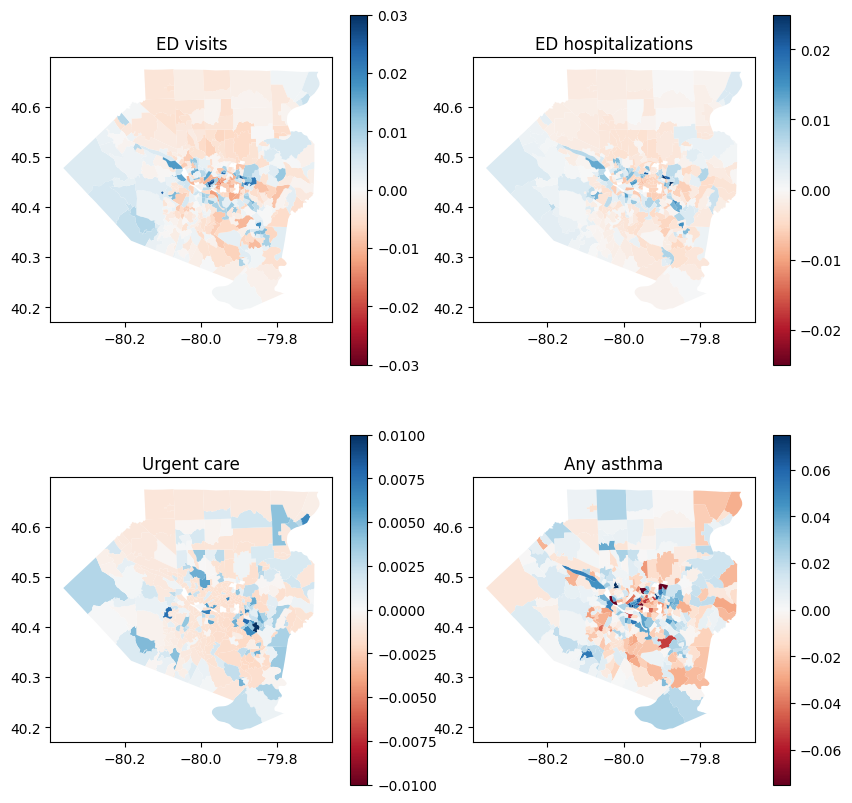

In [30]:
# what do the residuals look like?
fig, axs = plt.subplots(2, 2, figsize=(10, 10))
df_resid.plot(column="ED_visits_frac_resid", cmap="RdBu", legend=True, ax=axs[0,0], vmin=-0.03, vmax=0.03)
axs[0,0].set_title("ED visits")
df_resid.plot(column="ED_hosp_frac_resid", cmap="RdBu", legend=True, ax=axs[0,1], vmin=-0.025, vmax=0.025)
axs[0,1].set_title("ED hospitalizations")
df_resid.plot(column="UC_visits_frac_resid", cmap="RdBu", legend=True, ax=axs[1,0], vmin=-0.01, vmax=0.01)
axs[1,0].set_title("Urgent care")
df_resid.plot(column="Asthma_use_frac_resid", cmap="RdBu", legend=True, ax=axs[1,1], vmin=-0.075, vmax=0.075)
axs[1,1].set_title("Any asthma")

The model is overpredicting emergency care in the north but underpredicting in the west.

These residuals look a bit clustered, but are they truly spatially autocorrelated? We can check Moran's I to see, but it's not obvious what choice of spatial weights is appropriate for this test. Arguably, any spatial autocorrelation is a problem, because it indicates that the model's functioning depends on the spatial region.

In [31]:
res = []
for col in dep_vars:
    for name in to_test.keys():
        moran = Moran(df_resid["{}_resid".format(col)], ws[name])
        res.append({"dep_var": col, "weight": name, "I": moran.I, "p": moran.p_sim})

res_df = pd.DataFrame(res)
res_df.loc[res_df.p < 0.05]

/home/eli/.cache/pypoetry/virtualenvs/air-brain-tDLovGh8-py3.12/lib/python3.12/site-packages/esda/moran.py:251: RuntimeWarning: invalid value encountered in scalar power
  self.seI_norm = self.VI_norm ** (1 / 2.0)
/home/eli/.cache/pypoetry/virtualenvs/air-brain-tDLovGh8-py3.12/lib/python3.12/site-packages/esda/moran.py:264: RuntimeWarning: invalid value encountered in scalar power
  self.seI_rand = VIR ** (1 / 2.0)


,dep_var,weight,I,p
0,ED_visits_frac,queen,0.303716,0.001
8,ED_hosp_frac,queen,0.223597,0.001
14,ED_hosp_frac,Gaussian_30,-0.000022,0.020
15,ED_hosp_frac,Gaussian_35,-0.000022,0.022
16,UC_visits_frac,queen,0.107839,0.001
17,UC_visits_frac,Gaussian_5,0.057670,0.015
24,Asthma_use_frac,queen,0.189420,0.001


In general, the residuals only look autocorrelated under Queen's contiguity. Census tracts that are adjacent are more likely to have similar errors for the air quality only model.

## Air quality alone: SLX model and its residuals

We already know that we want to model air quality with the spatial lag of the air quality. Does including the spatial lag explicitly in the model help reduce spatial dependence in the errors?

In [32]:
# compute the spatial lag of all independent variables (air quality + demographics)
# using row-standardized weights defined above
lag_dict = {"PM25": "Gaussian_15",
            "dpm": "Gaussian_5",
            "PM25_dpm_mean": "Gaussian_5", # TODO
            "lowincome": "queen",
            "poc": "queen",
            "poc_lowincome_pca": "queen", # TODO
           }
dfx = df.copy()
for col, lag in lag_dict.items():
    new_col = make_lag(df, col, to_test[lag][0], to_test[lag][1])
    dfx = pd.concat([dfx, new_col], axis=1)

In [33]:
# fit the air quality with spatial lag models and save the residuals
df_resid = df.copy()
for col in dep_vars:
    mod = sm.OLS(dfx[col], dfx[indep_to_use[col] + ["w_{}".format(x) for x in indep_to_use[col]] + ["intercept"]])
    res = mod.fit()
    df_resid["{}_resid".format(col)] = res.resid

In [34]:
res = []
for col in dep_vars:
    for name in to_test.keys():
        moran = Moran(df_resid["{}_resid".format(col)], ws[name])
        res.append({"dep_var": col, "weight": name, "I": moran.I, "p": moran.p_sim})

res_df = pd.DataFrame(res)
res_df.loc[res_df.p < 0.05]

/home/eli/.cache/pypoetry/virtualenvs/air-brain-tDLovGh8-py3.12/lib/python3.12/site-packages/esda/moran.py:251: RuntimeWarning: invalid value encountered in scalar power
  self.seI_norm = self.VI_norm ** (1 / 2.0)
/home/eli/.cache/pypoetry/virtualenvs/air-brain-tDLovGh8-py3.12/lib/python3.12/site-packages/esda/moran.py:264: RuntimeWarning: invalid value encountered in scalar power
  self.seI_rand = VIR ** (1 / 2.0)


,dep_var,weight,I,p
0,ED_visits_frac,queen,0.299437,0.001
8,ED_hosp_frac,queen,0.209426,0.001
16,UC_visits_frac,queen,0.101924,0.001
17,UC_visits_frac,Gaussian_5,0.050369,0.038
24,Asthma_use_frac,queen,0.187257,0.001


Not really: all these models still show spatial correlation in the errors (according to Queen's contiguity). We will still need to include a spatial lag term in the residuals, even when including the spatial lag of the independent variables.

## Air quality alone: spatial error

Does including the spatial lag in the error term change the conclusions from the plain OLS model?

In [35]:
# fit the air quality model using the lag error and save the results
ols_res = dict()
for dep in dep_vars:
    indep = indep_to_use[dep]
    res = spreg.GM_Error_Het(dfx[[dep]].values, dfx[indep].values, w=ws["queen"], name_y=dep, name_x=indep)
    ols_res[dep] = res
spreg2df(ols_res)[["coef", "std err", "p"]].style.pipe(p_col_style)

The results are generally the same as the model without spatial error, except that diesel PM is no longer a signficant predictor of emergency department hospitalizations.

## Air quality alone: spatial Durbin error model (SLX + spatial error)

Combining spatial lag in the error term as well as the independent variables is called a spatial Durbin error model. The results above suggest we should use queen's contiguity as the spatial weighting for the error term.

Does including the spatial lag in the error term change the conclusions from the SLX model alone?

In [36]:
# fit the air quality model using the lag error and spatial lag and save the results
ols_res = dict()
for dep in dep_vars:
    indep = indep_to_use[dep] + ["w_{}".format(x) for x in indep_to_use[dep]]
    res = spreg.GM_Error_Het(dfx[[dep]].values, dfx[indep].values, w=ws["queen"], name_y=dep, name_x=indep)
    ols_res[dep] = res
spreg2df(ols_res)[["coef", "std err", "p"]].style.pipe(p_col_style)

The conclusions with the spatial Durbin model are the same as the SLX model alone: PM 2.5 is a significant predictor of childhood asthma encounters for all cases except urgent care visits. Diesel PM is not significant for any outcomes.

## Air quality and demographics: plain OLS and its residuals

Do we see the same spatial relationship in the errors of the model controlling for demographics?

In [37]:
# fit the air quality + demographics models and save the residuals
ols_res = dict()
df_resid = df.copy()
for col in dep_vars:
    mod = sm.OLS(df[col], df[combo_indep_vars[col] + ["intercept"]])
    res = mod.fit()
    df_resid["{}_resid".format(col)] = res.resid

Text(0.5, 1.0, 'Any asthma')

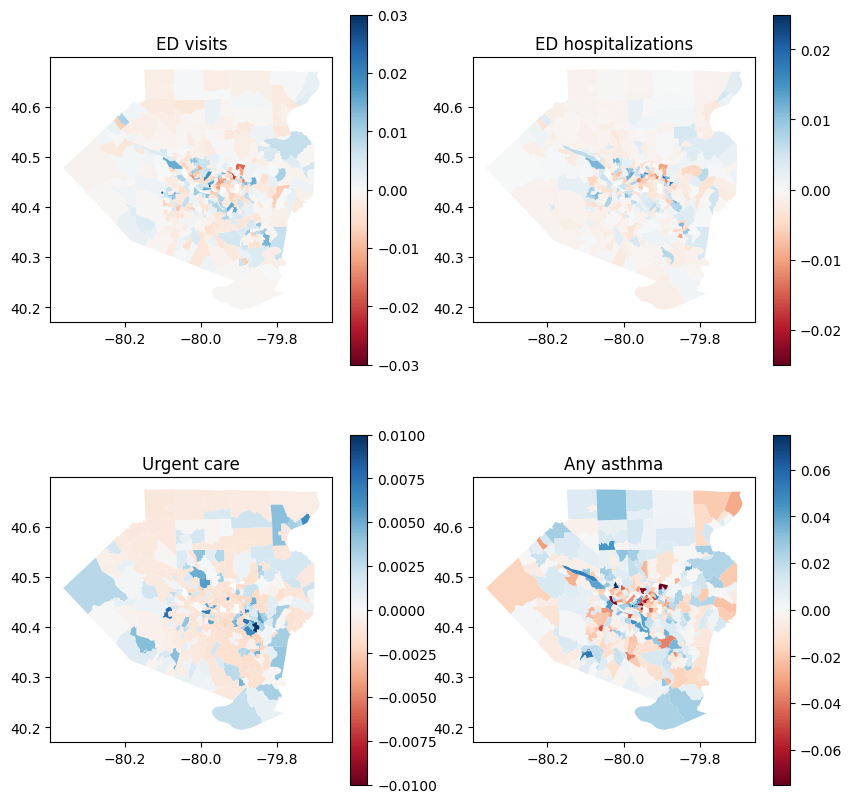

In [38]:
# what do the residuals look like?
fig, axs = plt.subplots(2, 2, figsize=(10, 10))
df_resid.plot(column="ED_visits_frac_resid", cmap="RdBu", legend=True, ax=axs[0,0], vmin=-0.03, vmax=0.03)
axs[0,0].set_title("ED visits")
df_resid.plot(column="ED_hosp_frac_resid", cmap="RdBu", legend=True, ax=axs[0,1], vmin=-0.025, vmax=0.025)
axs[0,1].set_title("ED hospitalizations")
df_resid.plot(column="UC_visits_frac_resid", cmap="RdBu", legend=True, ax=axs[1,0], vmin=-0.01, vmax=0.01)
axs[1,0].set_title("Urgent care")
df_resid.plot(column="Asthma_use_frac_resid", cmap="RdBu", legend=True, ax=axs[1,1], vmin=-0.075, vmax=0.075)
axs[1,1].set_title("Any asthma")

In [39]:
res = []
for col in dep_vars:
    for name in to_test.keys():
        moran = Moran(df_resid["{}_resid".format(col)], ws[name])
        res.append({"dep_var": col, "weight": name, "I": moran.I, "p": moran.p_sim})

res_df = pd.DataFrame(res)
res_df.loc[res_df.p < 0.05]

/home/eli/.cache/pypoetry/virtualenvs/air-brain-tDLovGh8-py3.12/lib/python3.12/site-packages/esda/moran.py:251: RuntimeWarning: invalid value encountered in scalar power
  self.seI_norm = self.VI_norm ** (1 / 2.0)
/home/eli/.cache/pypoetry/virtualenvs/air-brain-tDLovGh8-py3.12/lib/python3.12/site-packages/esda/moran.py:264: RuntimeWarning: invalid value encountered in scalar power
  self.seI_rand = VIR ** (1 / 2.0)


,dep_var,weight,I,p
0,ED_visits_frac,queen,0.121812,0.001
1,ED_visits_frac,Gaussian_5,0.011980,0.030
8,ED_hosp_frac,queen,0.075588,0.008
9,ED_hosp_frac,Gaussian_5,0.006841,0.001
16,UC_visits_frac,queen,0.107289,0.002
17,UC_visits_frac,Gaussian_5,0.060461,0.008
24,Asthma_use_frac,queen,0.136992,0.001
25,Asthma_use_frac,Gaussian_5,0.048978,0.044


The model with demographics also shows spatial autocorrelation in the residuals, as expected.

## Air quality and demographics: SLX model and its residuals

In [40]:
# fit the air quality with spatial lag models and save the residuals
df_resid = df.copy()
for col in dep_vars:
    mod = sm.OLS(dfx[col], dfx[combo_indep_vars[col] + ["w_{}".format(x) for x in combo_indep_vars[col]] + ["intercept"]])
    res = mod.fit()
    df_resid["{}_resid".format(col)] = res.resid

In [41]:
res = []
for col in dep_vars:
    for name in to_test.keys():
        moran = Moran(df_resid["{}_resid".format(col)], ws[name])
        res.append({"dep_var": col, "weight": name, "I": moran.I, "p": moran.p_sim})

res_df = pd.DataFrame(res)
res_df.loc[res_df.p < 0.05]

/home/eli/.cache/pypoetry/virtualenvs/air-brain-tDLovGh8-py3.12/lib/python3.12/site-packages/esda/moran.py:251: RuntimeWarning: invalid value encountered in scalar power
  self.seI_norm = self.VI_norm ** (1 / 2.0)
/home/eli/.cache/pypoetry/virtualenvs/air-brain-tDLovGh8-py3.12/lib/python3.12/site-packages/esda/moran.py:264: RuntimeWarning: invalid value encountered in scalar power
  self.seI_rand = VIR ** (1 / 2.0)


,dep_var,weight,I,p
0,ED_visits_frac,queen,0.132790,0.001
8,ED_hosp_frac,queen,0.073441,0.011
9,ED_hosp_frac,Gaussian_5,0.007126,0.006
16,UC_visits_frac,queen,0.096827,0.001
17,UC_visits_frac,Gaussian_5,0.050241,0.033
24,Asthma_use_frac,queen,0.135309,0.001


Again, there are still spatially autocorrelated errors in the SLX model with demographics.

## Air quality and demographics: spatial error

Do the conclusions of the plain OLS model with air quality and demographics change if we include spatial error?

In [42]:
# fit the air quality model using the lag error and spatial lag and save the results
ols_res = dict()
for dep in dep_vars:
    indep = combo_indep_vars[dep]
    res = spreg.GM_Error_Het(dfx[[dep]].values, dfx[indep].values, w=ws["queen"], name_y=dep, name_x=indep)
    ols_res[dep] = res
spreg2df(ols_res)[["coef", "std err", "p"]].style.pipe(p_col_style)

No, the conclusions do not change.

## Air quality and demographics: spatial Durbin error model (SLX + spatial error)

Do the conclusions of the SLX model with air quality and demographics change if we include spatial error?

In [43]:
# fit the air quality model using the lag error and spatial lag and save the results
ols_res = dict()
for dep in dep_vars:
    indep = combo_indep_vars[dep] + ["w_{}".format(x) for x in combo_indep_vars[dep]]
    res = spreg.GM_Error_Het(dfx[[dep]].values, dfx[indep].values, w=ws["queen"], name_y=dep, name_x=indep)
    ols_res[dep] = res
spreg2df(ols_res)[["coef", "std err", "p"]].style.pipe(p_col_style)

As before, air quality is not a significant predictor of any outcome, although the spatial lag of PM 2.5 is predictive of urgent care visits. Demographics are now significantly predictive of all outcomes except urgent care visits, where previously they were predictive of all outcomes.

# Spatial lag of the outcomes

It doesn't really make sense to use the spatial lag of the asthma outcomes, which would indicate that the asthma incidence in one region directly influences the asthma incidence in another. But I wanted to keep these analysis here, mostly as notes for future work.

In [44]:
res_dict = dict()
for dep in dep_vars:
    indep = indep_to_use[dep]
    res = spreg.GM_Lag(df[[dep]].values, df[indep].values, w=ws["queen"], name_y=dep, name_x=indep)
    res_dict[dep] = res
spreg2df(res_dict, name_attr="name_z")[["coef", "std err", "p"]].style.pipe(p_col_style)

In [45]:
res_dict = dict()
for dep in dep_vars:
    indep = combo_indep_vars[dep]
    res = spreg.GM_Lag(df[[dep]].values, df[indep].values, w=ws["queen"], name_y=dep, name_x=indep)
    res_dict[dep] = res
spreg2df(res_dict, name_attr="name_z")[["coef", "std err", "p"]].style.pipe(p_col_style)